# Cookie Cats A/B Test — 가설 검정

**비즈니스 질문:** Gate를 레벨 30에서 레벨 40으로 옮기면 D7 리텐션이 유의미하게 달라지는가?

| 가설 | 내용 |
|---|---|
| H₀ (귀무가설) | 게이트 위치는 D7 리텐션에 영향을 미치지 않는다: π_gate30 = π_gate40 |
| H₁ (대립가설) | 게이트 위치는 D7 리텐션에 영향을 미친다: π_gate30 ≠ π_gate40 |
| 유의수준 α | 0.05 |

**분석 순서:** ① 카이제곱 검정 → ② Two-proportion Z-test → ③ Bootstrap → ④ 순열 검정

## 1. 데이터 불러오기 & 전처리 (EDA와 동일)

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib import font_manager as fm
from scipy import stats

# 한글 폰트 자동 탐지 (OS 무관)
preferred_fonts = [
    'AppleGothic', 'Malgun Gothic', 'NanumGothic',
    'Noto Sans CJK KR', 'Arial Unicode MS',
]
available_fonts = {f.name for f in fm.fontManager.ttflist}
font = next((name for name in preferred_fonts if name in available_fonts), 'DejaVu Sans')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = font
plt.rcParams['font.sans-serif'] = [font, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

if font == 'DejaVu Sans':
    warnings.filterwarnings('ignore', message=r'Glyph .* missing from current font\.')

# 데이터 로드
df_raw = pd.read_csv('../data/cookie_cats.csv')

# --- EDA 동일 전처리 ---
OUTLIER_UPPER = 30_000
df = df_raw[df_raw['sum_gamerounds'] <= OUTLIER_UPPER].copy()  # 극단 이상치 제거
df = df[df['sum_gamerounds'] > 0].copy()                        # 0라운드 유저 제거

print(f"원본         : {len(df_raw):>7,}명")
print(f"이상치 제거  : {(df_raw['sum_gamerounds'] > OUTLIER_UPPER).sum():>7,}명 제거")
print(f"0라운드 제거 : {(df_raw['sum_gamerounds'] == 0).sum():>7,}명 제거")
print(f"최종 분석 수 : {len(df):>7,}명")
print(f"사용 폰트    : {font}")
df['version'].value_counts()

원본         :  90,189명
이상치 제거  :       1명 제거
0라운드 제거 :   3,994명 제거
최종 분석 수 :  86,194명
사용 폰트    : AppleGothic


version
gate_40    43432
gate_30    42762
Name: count, dtype: int64

## 2. 기술 통계 — 분할표 (Contingency Table)

In [2]:
gate30 = df[df['version'] == 'gate_30']
gate40 = df[df['version'] == 'gate_40']

n30 = len(gate30)
n40 = len(gate40)

# D7 Retention 집계
r30_7 = gate30['retention_7'].sum()
r40_7 = gate40['retention_7'].sum()

p30 = r30_7 / n30
p40 = r40_7 / n40

# 분할표
ct = pd.DataFrame({
    'Retained (True)' : [r30_7,        r40_7       ],
    'Churned (False)' : [n30 - r30_7,  n40 - r40_7 ],
    'Total'           : [n30,          n40          ],
}, index=['gate_30', 'gate_40'])

print('=== 분할표 (D7 Retention) ===')
print(ct.to_string())
print()
print(f'gate_30 D7 Retention     : {p30*100:.4f}%  ({r30_7:,}/{n30:,})')
print(f'gate_40 D7 Retention     : {p40*100:.4f}%  ({r40_7:,}/{n40:,})')
print(f'차이 (gate_30 - gate_40) : {(p30 - p40)*100:+.4f}%p')

=== 분할표 (D7 Retention) ===
         Retained (True)  Churned (False)  Total
gate_30             8485            34277  42762
gate_40             8266            35166  43432

gate_30 D7 Retention     : 19.8424%  (8,485/42,762)
gate_40 D7 Retention     : 19.0321%  (8,266/43,432)
차이 (gate_30 - gate_40) : +0.8103%p


## 3. 카이제곱 검정 (Chi-square Test)

범주형 변수(그룹) × 이진 변수(리텐션)의 **독립성 검정**.

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

- H₀: gate 위치와 D7 리텐션은 독립이다 (π_30 = π_40)
- 조건: 모든 기대빈도 ≥ 5 (대규모 데이터이므로 충족 예상)

- 카이제곱 검정의 주요 가정
1. 각 유저는 서로 독립이어야함
2. 셀 값은 인원수
3. 무작위 배정이 되어있어야함
4. 기대빈도가 충분히 클것 

In [3]:
ct_vals = ct[['Retained (True)', 'Churned (False)']].values

chi2_stat, p_chi2, dof, expected = stats.chi2_contingency(ct_vals)

print('=== 카이제곱 검정 결과 ===')
print(f'chi2 통계량 : {chi2_stat:.6f}')
print(f'p-value     : {p_chi2:.6f}')
print(f'자유도      : {dof}')
print()
print('기대빈도:')
print(pd.DataFrame(expected, index=['gate_30', 'gate_40'],
                   columns=['E_Retained', 'E_Churned']).round(2))
print()
if p_chi2 < 0.05:
    print(f'p = {p_chi2:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
else:
    print(f'p = {p_chi2:.4f} >= alpha 0.05  ->  H0 채택')

=== 카이제곱 검정 결과 ===
chi2 통계량 : 8.984878
p-value     : 0.002722
자유도      : 1

기대빈도:
         E_Retained  E_Churned
gate_30      8310.4    34451.6
gate_40      8440.6    34991.4

p = 0.0027 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.


- 기대빈도(E) : 두 변수가 독립이라고 가정했을때 각 칸에 이론적으로 기대되는 인원수.
- 관측빈도(O) : 실제 데이터에서 나온값

이 두 차이가 클수록 chi2통계량도 커짐.

- p값은 “귀무가설이 맞다고 할 때, 지금 관측한 통계량 이상으로 극단적인 값이 나올 확률”

---

## 4. Two-proportion Z-test

비율 차이에 대한 정규근사 검정. 표본이 충분히 클 때 카이제곱과 동등한 결과를 제공하며,  
**신뢰구간(CI)** 을 직접 산출할 수 있다는 장점이 있다.

$$Z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})\left(\frac{1}{n_1}+\frac{1}{n_2}\right)}}$$

합동 비율 $\hat{p} = \dfrac{X_1 + X_2}{n_1 + n_2}$

- 귀무가설 : 두 비율은 같다. 

**귀무가설이 참일 때(두 비율이 같을 때), 우리가 관측한 차이만큼 극단적인 값이 정규분포 상 어느 지점에 위치하는가**

#### Z-test의 가정
1. 각 관측값이 서로 독립적
2. gate_30 그룹과 gate_40 그룹이 서로 독립적(한유저는 반드시 한 그룹)
3. 충분한 샘플 크기, 이진결과, 랜덤샘플링

=== Two-proportion Z-test 결과 ===
Z 통계량             : 3.006087
p-value              : 0.002646
95% CI (p30 - p40)  : [0.2820%p, 1.3387%p]

p = 0.0026 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.
  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.


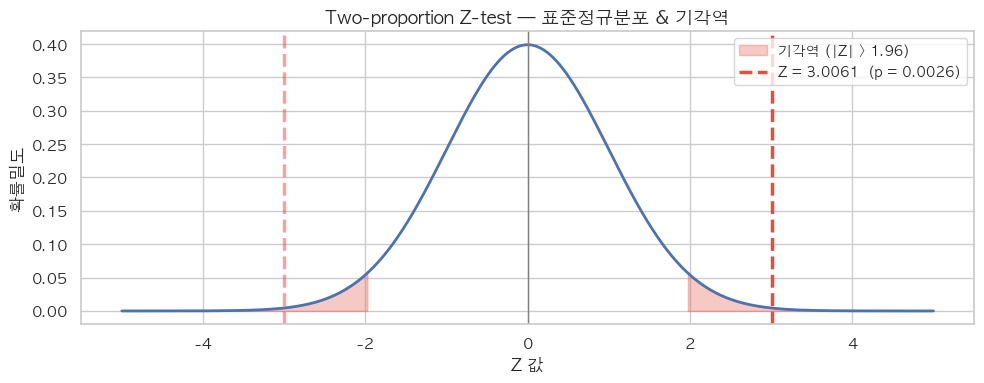

In [4]:
# 합동 비율 (귀무가설 하)
p_pool = (r30_7 + r40_7) / (n30 + n40)
se_pooled = np.sqrt(p_pool * (1 - p_pool) * (1/n30 + 1/n40))

z_stat = (p30 - p40) / se_pooled
p_z    = 2 * (1 - stats.norm.cdf(abs(z_stat)))  # 양측

# 95% 신뢰구간 (비합동 SE)
se_diff = np.sqrt(p30*(1-p30)/n30 + p40*(1-p40)/n40)
z_crit  = stats.norm.ppf(0.975)
ci_lo   = (p30 - p40) - z_crit * se_diff
ci_hi   = (p30 - p40) + z_crit * se_diff

print('=== Two-proportion Z-test 결과 ===')
print(f'Z 통계량             : {z_stat:.6f}')
print(f'p-value              : {p_z:.6f}')
print(f'95% CI (p30 - p40)  : [{ci_lo*100:.4f}%p, {ci_hi*100:.4f}%p]')
print()
if p_z < 0.05:
    print(f'p = {p_z:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
    if ci_lo > 0:
        print('  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.')
else:
    print(f'p = {p_z:.4f} >= alpha 0.05  ->  H0 채택')

# 시각화: 표준정규분포 위에 Z 통계량 표시
x = np.linspace(-5, 5, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, y, color='#4C72B0', linewidth=2)
ax.fill_between(x, y, where=(x <= -z_crit), color='#e74c3c', alpha=0.3, label=f'기각역 (|Z| > {z_crit:.2f})')
ax.fill_between(x, y, where=(x >=  z_crit), color='#e74c3c', alpha=0.3)
ax.axvline( z_stat, color='#e74c3c', linestyle='--', linewidth=2.5,
            label=f'Z = {z_stat:.4f}  (p = {p_z:.4f})')
ax.axvline(-z_stat, color='#e74c3c', linestyle='--', linewidth=2.5, alpha=0.5)
ax.axvline(0, color='grey', linewidth=1, linestyle='-')
ax.set_xlabel('Z 값', fontsize=12)
ax.set_ylabel('확률밀도', fontsize=12)
ax.set_title('Two-proportion Z-test — 표준정규분포 & 기각역', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 5. Bootstrap 검정

분포 가정 없이 재표본 추출(복원 추출)로 표본분포를 직접 추정.
각 그룹에서 독립적으로 재샘플링해서, 그 차이의 분포를 만든 것.

1. gate_30 / gate_40 각각에서 복원 추출 → D7 리텐션 차이 δ* 계산
2. 10,000회 반복 → 부트스트랩 분포 구축
3. **95% CI**: 부트스트랩 분포의 2.5th ~ 97.5th 백분위수
4. **p-value**: 귀무가설(차이 = 0) 중심으로 이동한 분포에서 관찰값보다 극단적인 비율

In [5]:
np.random.seed(42)
N_BOOTSTRAP = 10_000

ret_30 = gate30['retention_7'].values.astype(int)
ret_40 = gate40['retention_7'].values.astype(int)

boot_diffs = np.array([
    np.random.choice(ret_30, size=len(ret_30), replace=True).mean() -
    np.random.choice(ret_40, size=len(ret_40), replace=True).mean()
    for _ in range(N_BOOTSTRAP)
])

observed_diff = p30 - p40

# 95% 신뢰구간 (백분위수 방법)
ci_boot_lo, ci_boot_hi = np.percentile(boot_diffs, [2.5, 97.5])

# p-value: 귀무가설 중심으로 이동 후 관찰값 이상 극단치 비율
boot_null = boot_diffs - boot_diffs.mean()
p_boot    = np.mean(np.abs(boot_null) >= np.abs(observed_diff))

print('=== Bootstrap 검정 결과 ===')
print(f'반복 횟수             : {N_BOOTSTRAP:,}회')
print(f'관찰된 차이 (p30-p40) : {observed_diff*100:+.4f}%p')
print(f'Bootstrap 평균 차이   : {boot_diffs.mean()*100:+.4f}%p')
print(f'Bootstrap 표준편차    : {boot_diffs.std()*100:.4f}%p')
print(f'95% CI                : [{ci_boot_lo*100:.4f}%p, {ci_boot_hi*100:.4f}%p]')
print(f'Bootstrap p-value     : {p_boot:.4f}')
print()
if p_boot < 0.05:
    print(f'p = {p_boot:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
    if ci_boot_lo > 0:
        print('  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.')
else:
    print(f'p = {p_boot:.4f} >= alpha 0.05  ->  H0 채택')

=== Bootstrap 검정 결과 ===
반복 횟수             : 10,000회
관찰된 차이 (p30-p40) : +0.8103%p
Bootstrap 평균 차이   : +0.8076%p
Bootstrap 표준편차    : 0.2723%p
95% CI                : [0.2686%p, 1.3507%p]
Bootstrap p-value     : 0.0033

p = 0.0033 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.
  95% CI 전체가 0 초과 -> gate_30의 D7 리텐션이 유의미하게 높다.


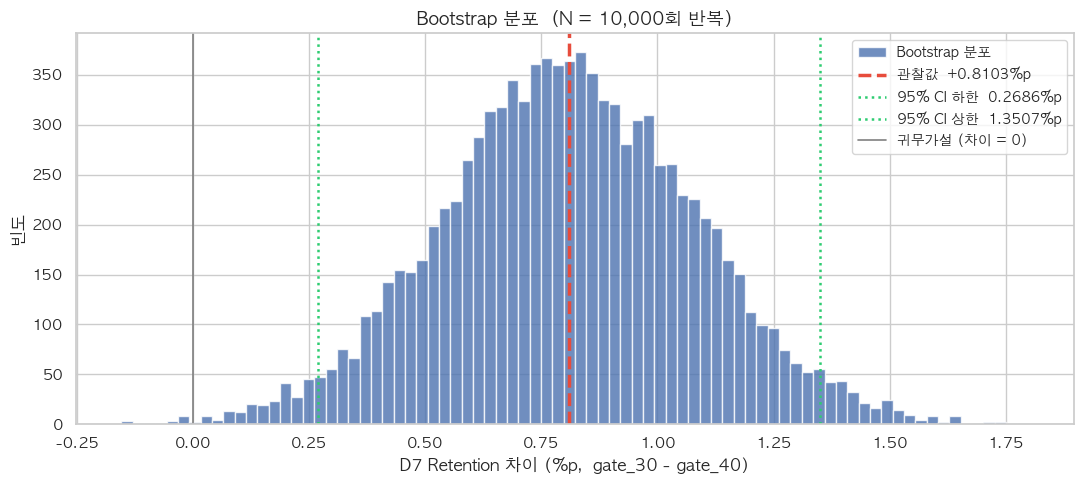

In [6]:
# 부트스트랩 분포 시각화
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(boot_diffs * 100, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8,
        label='Bootstrap 분포')
ax.axvline(observed_diff  * 100, color='#e74c3c', linewidth=2.5, linestyle='--',
           label=f'관찰값  {observed_diff*100:+.4f}%p')
ax.axvline(ci_boot_lo * 100, color='#2ecc71', linewidth=1.8, linestyle=':',
           label=f'95% CI 하한  {ci_boot_lo*100:.4f}%p')
ax.axvline(ci_boot_hi * 100, color='#2ecc71', linewidth=1.8, linestyle=':',
           label=f'95% CI 상한  {ci_boot_hi*100:.4f}%p')
ax.axvline(0, color='grey', linewidth=1.2, linestyle='-', label='귀무가설 (차이 = 0)')

ax.set_xlabel('D7 Retention 차이 (%p,  gate_30 - gate_40)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title(f'Bootstrap 분포  (N = {N_BOOTSTRAP:,}회 반복)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 6. 순열 검정 (Permutation Test)

분포 가정이 전혀 없는 **비모수적** 정확 검정. 귀무가설("그룹 레이블은 무관하다")을 직접 시뮬레이션한다.

**원리**

1. 전체 retention_7 값을 하나의 풀(pool)에 합친다.
2. 풀에서 n₃₀개 / n₄₀개로 무작위 분할 → 두 그룹 간 비율 차이 δ* 계산.
3. 10,000회 반복 → **귀무분포(null distribution)** 구축.
4. **p-value** = |δ*| ≥ |δ_observed| 인 비율.

> Bootstrap은 원래 그룹을 유지하며 재표본 추출하지만,  
> 순열 검정은 **레이블을 섞어** 귀무가설이 참일 때의 분포를 구성한다는 점이 다르다.

=== 순열 검정 결과 ===
반복 횟수             : 10,000회
관찰된 차이 (p30-p40) : +0.8103%p
순열 분포 평균        : -0.002182%p  (≈ 0 이어야 정상)
순열 분포 표준편차    : 0.2663%p
95% CI (귀무분포)     : [-0.5171%p, 0.5226%p]
p-value               : 0.0023

p = 0.0023 < alpha 0.05  ->  H0 기각
  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.


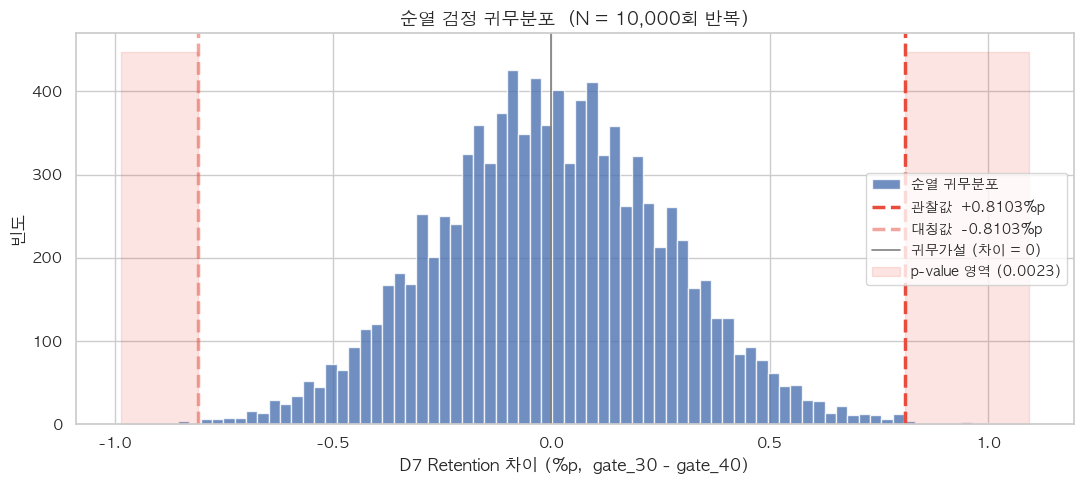

In [7]:
np.random.seed(42)
N_PERM = 10_000

# 전체 풀
pool = df['retention_7'].values.astype(int)

perm_diffs = np.empty(N_PERM)
for i in range(N_PERM):
    shuffled = np.random.permutation(pool)
    perm_diffs[i] = shuffled[:n30].mean() - shuffled[n30:n30 + n40].mean()

# p-value: 관찰값보다 극단적인(절댓값 기준) 비율
p_perm = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

ci_perm_lo, ci_perm_hi = np.percentile(perm_diffs, [2.5, 97.5])

print('=== 순열 검정 결과 ===')
print(f'반복 횟수             : {N_PERM:,}회')
print(f'관찰된 차이 (p30-p40) : {observed_diff*100:+.4f}%p')
print(f'순열 분포 평균        : {perm_diffs.mean()*100:+.6f}%p  (≈ 0 이어야 정상)')
print(f'순열 분포 표준편차    : {perm_diffs.std()*100:.4f}%p')
print(f'95% CI (귀무분포)     : [{ci_perm_lo*100:.4f}%p, {ci_perm_hi*100:.4f}%p]')
print(f'p-value               : {p_perm:.4f}')
print()
if p_perm < 0.05:
    print(f'p = {p_perm:.4f} < alpha 0.05  ->  H0 기각')
    print('  게이트 위치는 D7 리텐션에 통계적으로 유의미한 영향을 미친다.')
else:
    print(f'p = {p_perm:.4f} >= alpha 0.05  ->  H0 채택')

# 시각화: 귀무분포 + 관찰값
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(perm_diffs * 100, bins=80, color='#4C72B0', edgecolor='white', alpha=0.8,
        label='순열 귀무분포')
ax.axvline( observed_diff * 100, color='#e74c3c', linewidth=2.5, linestyle='--',
            label=f'관찰값  {observed_diff*100:+.4f}%p')
ax.axvline(-observed_diff * 100, color='#e74c3c', linewidth=2.5, linestyle='--', alpha=0.5,
            label=f'대칭값  {-observed_diff*100:+.4f}%p')
ax.axvline(0, color='grey', linewidth=1.2, linestyle='-', label='귀무가설 (차이 = 0)')

# p-value 영역 음영 — 양측 검정이므로 좌·우 꼬리 모두 표시
# (히스토그램 그린 뒤 ylim 확정 후 참조)
ymax = ax.get_ylim()[1]
ax.fill_between(                                                 # 우측 꼬리
    np.linspace(observed_diff * 100, perm_diffs.max() * 100, 200),
    0, ymax, color='#e74c3c', alpha=0.15, label=f'p-value 영역 ({p_perm:.4f})')
ax.fill_between(                                                 # 좌측 꼬리
    np.linspace(perm_diffs.min() * 100, -observed_diff * 100, 200),
    0, ymax, color='#e74c3c', alpha=0.15)

ax.set_xlabel('D7 Retention 차이 (%p,  gate_30 - gate_40)', fontsize=12)
ax.set_ylabel('빈도', fontsize=12)
ax.set_title(f'순열 검정 귀무분포  (N = {N_PERM:,}회 반복)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 7. Secondary KPI — D1 잔존율 검정

D7 잔존율(Primary KPI)에서 유의한 차이가 확인되었다.  
D1 잔존율(설치 다음날 재방문)에서도 그룹 간 차이가 있는지 동일한 방법으로 검정한다.

- **H₀:** gate_30과 gate_40의 D1 잔존율은 같다 (π₃₀ = π₄₀)
- **H₁:** D1 잔존율은 그룹 간 차이가 있다 (π₃₀ ≠ π₄₀)
- **α:** 0.05

In [8]:
# D1 분할표
r30_1 = gate30['retention_1'].sum()
r40_1 = gate40['retention_1'].sum()
p30_1 = r30_1 / n30
p40_1 = r40_1 / n40

ct_d1 = pd.DataFrame({
    'Retained (True)' : [r30_1,        r40_1       ],
    'Churned (False)' : [n30 - r30_1,  n40 - r40_1 ],
    'Total'           : [n30,          n40          ],
}, index=['gate_30', 'gate_40'])

print('=== 분할표 (D1 Retention) ===')
print(ct_d1.to_string())
print(f'\ngate_30 D1 Retention     : {p30_1*100:.4f}%  ({r30_1:,}/{n30:,})')
print(f'gate_40 D1 Retention     : {p40_1*100:.4f}%  ({r40_1:,}/{n40:,})')
print(f'차이 (gate_30 - gate_40) : {(p30_1 - p40_1)*100:+.4f}%p')

# --- 카이제곱 ---
ct_d1_vals = ct_d1[['Retained (True)', 'Churned (False)']].values
chi2_d1, p_chi2_d1, dof_d1, _ = stats.chi2_contingency(ct_d1_vals)

print('\n=== D1 카이제곱 검정 ===')
print(f'chi2 = {chi2_d1:.4f},  p = {p_chi2_d1:.4f}  →  {"H0 기각" if p_chi2_d1 < 0.05 else "H0 채택 (유의하지 않음)"}')

# --- Bootstrap ---
np.random.seed(42)
ret_30_1 = gate30['retention_1'].values.astype(int)
ret_40_1 = gate40['retention_1'].values.astype(int)

boot_diffs_d1 = np.array([
    np.random.choice(ret_30_1, size=len(ret_30_1), replace=True).mean() -
    np.random.choice(ret_40_1, size=len(ret_40_1), replace=True).mean()
    for _ in range(N_BOOTSTRAP)
])

obs_diff_d1          = p30_1 - p40_1
ci_d1_lo, ci_d1_hi   = np.percentile(boot_diffs_d1, [2.5, 97.5])
boot_null_d1         = boot_diffs_d1 - boot_diffs_d1.mean()
p_boot_d1            = np.mean(np.abs(boot_null_d1) >= np.abs(obs_diff_d1))

print('\n=== D1 Bootstrap 검정 ===')
print(f'관찰 차이 : {obs_diff_d1*100:+.4f}%p')
print(f'95% CI    : [{ci_d1_lo*100:.4f}%p, {ci_d1_hi*100:.4f}%p]')
print(f'p-value   : {p_boot_d1:.4f}  →  {"H0 기각" if p_boot_d1 < 0.05 else "H0 채택 (유의하지 않음)"}')
if ci_d1_lo <= 0 <= ci_d1_hi:
    print('  ⚠️  95% CI가 0을 포함 → 차이가 우연일 가능성 배제 불가')

=== 분할표 (D1 Retention) ===
         Retained (True)  Churned (False)  Total
gate_30            19993            22769  42762
gate_40            20073            23359  43432

gate_30 D1 Retention     : 46.7541%  (19,993/42,762)
gate_40 D1 Retention     : 46.2171%  (20,073/43,432)
차이 (gate_30 - gate_40) : +0.5371%p

=== D1 카이제곱 검정 ===
chi2 = 2.4767,  p = 0.1155  →  H0 채택 (유의하지 않음)

=== D1 Bootstrap 검정 ===
관찰 차이 : +0.5371%p
95% CI    : [-0.1350%p, 1.1882%p]
p-value   : 0.1111  →  H0 채택 (유의하지 않음)
  ⚠️  95% CI가 0을 포함 → 차이가 우연일 가능성 배제 불가


## 8. Secondary KPI — 게임 라운드 수 (Mann-Whitney U)

게임 라운드(`sum_gamerounds`) 분포는 극심한 우측 편중(right-skewed)이므로 정규성 가정이 필요한 t-test 적용이 부적합하다.  
비모수 검정인 **Mann-Whitney U**로 두 그룹의 분포 위치 차이를 검정한다.

- **H₀:** gate_30과 gate_40의 게임 라운드 분포는 같다
- **H₁:** 두 그룹의 분포가 다르다

**Mann-Whitney U의 원리:** 두 그룹을 합쳐 순위를 매겼을 때, 한 그룹의 값이 다른 그룹보다 더 높은 순위를 차지하는 빈도를 검정한다. 중앙값 기반 비교에 가까우며, 이상치에 강건하다.

=== Mann-Whitney U 검정 결과 ===
U 통계량 : 934,332,123
p-value  : 0.1177  →  H0 채택 (유의하지 않음)

=== 기술 통계 비교 ===
          중앙값    평균   Q1    Q3
gate_30  18.0  53.7  6.0  53.0
gate_40  18.0  53.7  6.0  55.0


/var/folders/y7/w247tcfd5q3bmlq5v2hz_thw0000gn/T/ipykernel_61168/1897647665.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='version', y='sum_gamerounds', ax=axes[0],


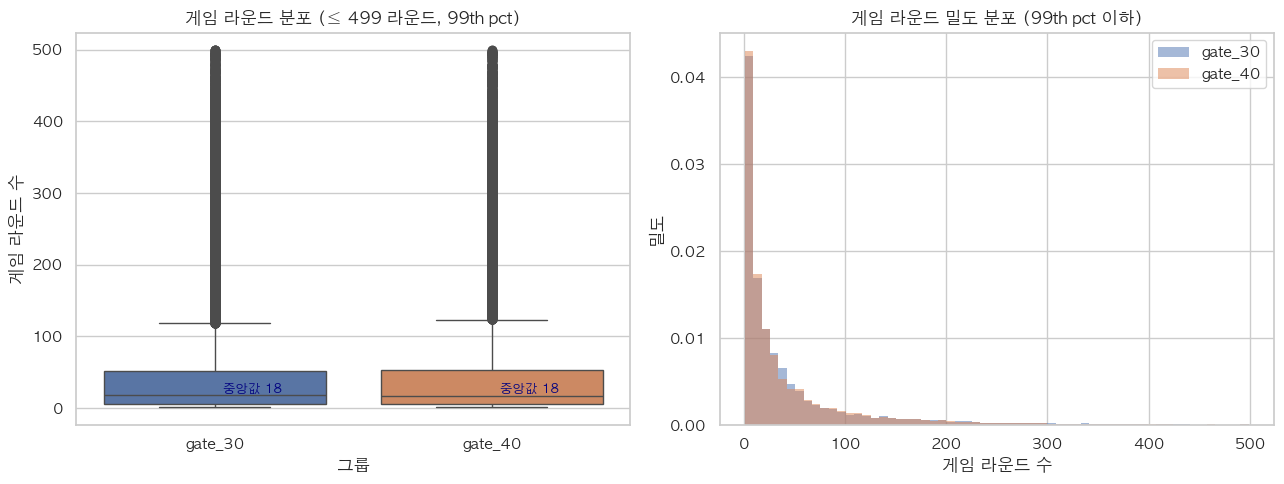

In [9]:
rounds_30 = gate30['sum_gamerounds'].values
rounds_40 = gate40['sum_gamerounds'].values

u_stat, p_mw = stats.mannwhitneyu(rounds_30, rounds_40, alternative='two-sided')

print('=== Mann-Whitney U 검정 결과 ===')
print(f'U 통계량 : {u_stat:,.0f}')
print(f'p-value  : {p_mw:.4f}  →  {"H0 기각" if p_mw < 0.05 else "H0 채택 (유의하지 않음)"}')
print()
print('=== 기술 통계 비교 ===')
stats_df = pd.DataFrame({
    '중앙값' : [np.median(rounds_30), np.median(rounds_40)],
    '평균'   : [np.mean(rounds_30),   np.mean(rounds_40)],
    'Q1'     : [np.percentile(rounds_30, 25), np.percentile(rounds_40, 25)],
    'Q3'     : [np.percentile(rounds_30, 75), np.percentile(rounds_40, 75)],
}, index=['gate_30', 'gate_40'])
print(stats_df.round(1).to_string())

# 시각화: boxplot + 밀도 히스토그램
p99_val  = np.percentile(df['sum_gamerounds'], 99)
df_plot  = df[df['sum_gamerounds'] <= p99_val]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot
sns.boxplot(data=df_plot, x='version', y='sum_gamerounds', ax=axes[0],
            palette={'gate_30': '#4C72B0', 'gate_40': '#DD8452'})
axes[0].set_title(f'게임 라운드 분포 (≤ {p99_val:.0f} 라운드, 99th pct)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('그룹')
axes[0].set_ylabel('게임 라운드 수')
for i, arr in enumerate([rounds_30, rounds_40]):
    med = np.median(arr)
    axes[0].text(i, med + 0.5, f'  중앙값 {med:.0f}', va='bottom', fontsize=9, color='navy')

# 밀도 히스토그램 (겹쳐서 비교)
for ver, color, arr in [('gate_30', '#4C72B0', rounds_30), ('gate_40', '#DD8452', rounds_40)]:
    clipped = arr[arr <= p99_val]
    axes[1].hist(clipped, bins=60, alpha=0.5, color=color, label=ver, density=True, edgecolor='none')
axes[1].set_title('게임 라운드 밀도 분포 (99th pct 이하)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('게임 라운드 수')
axes[1].set_ylabel('밀도')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. 효과 크기 (Cohen's h) & 검정력 분석

통계적 유의성은 "차이가 우연인가"를 판단하지만, **효과 크기**는 "차이가 얼마나 의미 있는가"를 측정한다.  
대규모 표본(86,194명)에서는 아주 작은 차이도 통계적으로 유의해질 수 있으므로, 두 지표를 함께 해석해야 한다.

#### Cohen's h — 비율 차이의 표준화 효과 크기

$$h = 2\arcsin(\sqrt{p_1}) - 2\arcsin(\sqrt{p_2})$$

| 기준 | 해석 |
|------|------|
| \|h\| < 0.2 | Small (작음) |
| 0.2 ≤ \|h\| < 0.5 | Medium (중간) |
| \|h\| ≥ 0.8 | Large (큼) |

#### 검정력 (Statistical Power)

H₁이 참일 때 H₀을 올바르게 기각할 확률. 80% 이상이면 충분한 검정력으로 판단한다.  
검정력이 충분하다면, "유의하지 않음"은 표본 부족이 아니라 실제 효과가 없음을 의미한다.

=== Cohen's h (효과 크기) ===
D7 잔존율: h = 0.0205  →  Small (매우 작음)
D1 잔존율: h = 0.0108  →  Small (매우 작음)

=== 검정력 (Statistical Power) ===
D7 잔존율: 85.22%  ✅ 충분 (≥ 80%)
D1 잔존율: 35.22%  ⚠️ 부족 (< 80%)

※ 표본이 충분히 크므로 0.81%p 수준의 작은 차이도 탐지 가능.
   D1이 유의하지 않은 이유는 표본 부족이 아니라 실제 효과가 미미하기 때문이다.


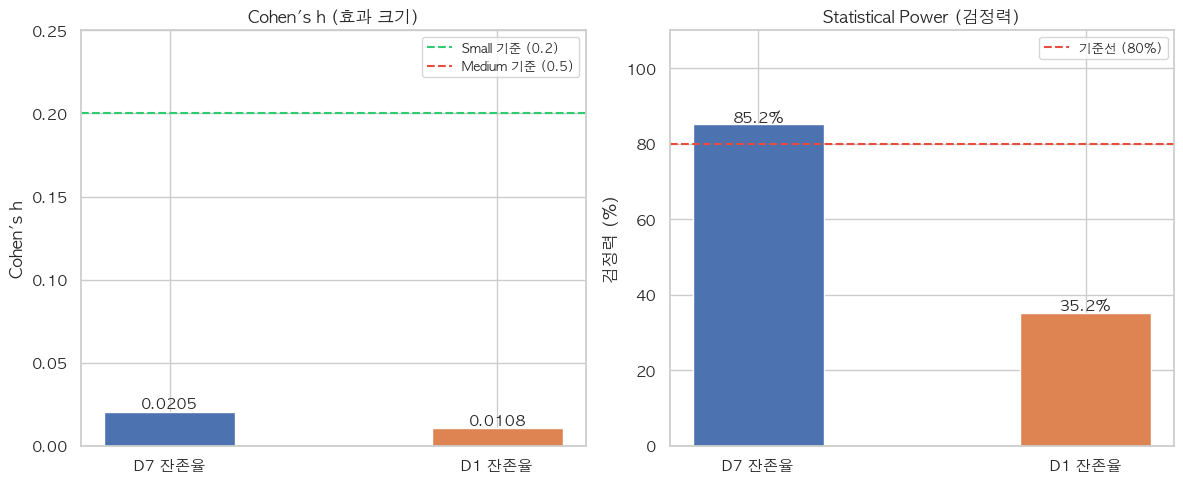

In [10]:
from scipy.stats import norm as sci_norm

def cohens_h(p1, p2):
    """비율 차이의 효과 크기 (Cohen's h)."""
    return 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))

def power_two_prop(p1, p2, n1, n2, alpha=0.05):
    """두 비율 차이의 검정력 (정규 근사, 양측)."""
    p_pool  = (p1 * n1 + p2 * n2) / (n1 + n2)
    se_null = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    se_alt  = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z_crit  = sci_norm.ppf(1 - alpha / 2)
    z_score = (abs(p1 - p2) - z_crit * se_null) / se_alt
    return sci_norm.cdf(z_score)

def h_label(h):
    a = abs(h)
    if a < 0.2: return 'Small (매우 작음)'
    if a < 0.5: return 'Medium (중간)'
    return 'Large (큼)'

h_d7     = cohens_h(p30,   p40)
h_d1     = cohens_h(p30_1, p40_1)
power_d7 = power_two_prop(p30,   p40,   n30, n40)
power_d1 = power_two_prop(p30_1, p40_1, n30, n40)

print("=== Cohen's h (효과 크기) ===")
print(f'D7 잔존율: h = {h_d7:.4f}  →  {h_label(h_d7)}')
print(f'D1 잔존율: h = {h_d1:.4f}  →  {h_label(h_d1)}')
print()
print('=== 검정력 (Statistical Power) ===')
print(f'D7 잔존율: {power_d7*100:.2f}%  {"✅ 충분 (≥ 80%)" if power_d7 >= 0.8 else "⚠️ 부족 (< 80%)"}')
print(f'D1 잔존율: {power_d1*100:.2f}%  {"✅ 충분 (≥ 80%)" if power_d1 >= 0.8 else "⚠️ 부족 (< 80%)"}')
print()
print('※ 표본이 충분히 크므로 0.81%p 수준의 작은 차이도 탐지 가능.')
print('   D1이 유의하지 않은 이유는 표본 부족이 아니라 실제 효과가 미미하기 때문이다.')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

kpis     = ['D7 잔존율', 'D1 잔존율']
h_vals   = [abs(h_d7),   abs(h_d1)]
pwr_vals = [power_d7 * 100, power_d1 * 100]
colors   = ['#4C72B0', '#DD8452']

# Cohen's h 막대 그래프
bars = axes[0].bar(kpis, h_vals, color=colors, width=0.4, edgecolor='white')
axes[0].axhline(0.2, color='#2ecc71', linestyle='--', linewidth=1.5, label='Small 기준 (0.2)')
axes[0].axhline(0.5, color='#e74c3c', linestyle='--', linewidth=1.5, label='Medium 기준 (0.5)')
for bar, val in zip(bars, h_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title("Cohen's h (효과 크기)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Cohen's h")
axes[0].set_ylim(0, 0.25)
axes[0].legend(fontsize=9)

# 검정력 막대 그래프
bars2 = axes[1].bar(kpis, pwr_vals, color=colors, width=0.4, edgecolor='white')
axes[1].axhline(80, color='#e74c3c', linestyle='--', linewidth=1.5, label='기준선 (80%)')
for bar, val in zip(bars2, pwr_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Statistical Power (검정력)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('검정력 (%)')
axes[1].set_ylim(0, 110)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. 검정 결과 종합

In [11]:
# ── D7 잔존율 (Primary KPI) ───────────────────────────────────────────
print('=' * 65)
print('  Primary KPI: D7 잔존율')
print('=' * 65)
summary_d7 = pd.DataFrame({
    '검정 방법'    : ['카이제곱', 'Z-test', 'Bootstrap', '순열 검정'],
    '통계량'       : [
        f'χ²={chi2_stat:.4f}',
        f'Z={z_stat:.4f}',
        f'diff={observed_diff*100:+.4f}%p',
        f'diff={observed_diff*100:+.4f}%p',
    ],
    'p-value'      : [f'{p_chi2:.4f}', f'{p_z:.4f}', f'{p_boot:.4f}', f'{p_perm:.4f}'],
    'H0 기각'      : ['✅' if p < 0.05 else '❌' for p in [p_chi2, p_z, p_boot, p_perm]],
    '95% CI'       : [
        '-',
        f'[{ci_lo*100:.4f}%p, {ci_hi*100:.4f}%p]',
        f'[{ci_boot_lo*100:.4f}%p, {ci_boot_hi*100:.4f}%p]',
        '-',
    ],
})
print(summary_d7.to_string(index=False))

# ── D1 잔존율 (Secondary KPI) ─────────────────────────────────────────
print()
print('=' * 65)
print('  Secondary KPI: D1 잔존율')
print('=' * 65)
summary_d1 = pd.DataFrame({
    '검정 방법'    : ['카이제곱', 'Bootstrap'],
    '통계량'       : [f'χ²={chi2_d1:.4f}', f'diff={obs_diff_d1*100:+.4f}%p'],
    'p-value'      : [f'{p_chi2_d1:.4f}', f'{p_boot_d1:.4f}'],
    'H0 기각'      : ['✅' if p < 0.05 else '❌' for p in [p_chi2_d1, p_boot_d1]],
    '95% CI'       : ['-', f'[{ci_d1_lo*100:.4f}%p, {ci_d1_hi*100:.4f}%p]'],
})
print(summary_d1.to_string(index=False))

# ── 게임 라운드 수 (Secondary KPI) ────────────────────────────────────
print()
print('=' * 65)
print('  Secondary KPI: 게임 라운드 수')
print('=' * 65)
print(f'Mann-Whitney U = {u_stat:,.0f},  p = {p_mw:.4f}  →  {"H0 기각" if p_mw < 0.05 else "H0 채택 (유의하지 않음)"}')

# ── 효과 크기 & 검정력 ────────────────────────────────────────────────
print()
print('=' * 65)
print("  효과 크기 (Cohen's h) & 검정력")
print('=' * 65)
eff_df = pd.DataFrame({
    'KPI'        : ['D7 잔존율', 'D1 잔존율'],
    "Cohen's h"  : [f'{abs(h_d7):.4f}', f'{abs(h_d1):.4f}'],
    '해석'        : [h_label(h_d7), h_label(h_d1)],
    '검정력'      : [f'{power_d7*100:.2f}%', f'{power_d1*100:.2f}%'],
    '충분 여부'   : ['✅' if power_d7 >= 0.8 else '⚠️', '✅' if power_d1 >= 0.8 else '⚠️'],
})
print(eff_df.to_string(index=False))

# ── 최종 비즈니스 결론 ────────────────────────────────────────────────
print()
print('=' * 65)
print('  최종 비즈니스 결론')
print('=' * 65)
print(f'gate_30 D7 Retention     : {p30*100:.4f}%')
print(f'gate_40 D7 Retention     : {p40*100:.4f}%')
print(f'차이 (gate_30 - gate_40) : {(p30 - p40)*100:+.4f}%p')
print()
all_d7_rejected = all(p < 0.05 for p in [p_chi2, p_z, p_boot, p_perm])
if all_d7_rejected:
    print('✅ D7: 4가지 검정 모두 H0 기각 → gate_30 D7 리텐션이 통계적으로 유의미하게 높다')
print('❌ D1: 검정 유의하지 않음   → 차이가 우연일 가능성 배제 불가 (CI가 0 포함)')
print('❌ 라운드: 유의하지 않음    → 두 그룹의 플레이량 차이 없음')
print()
print('→ Gate를 레벨 40으로 옮기면 D7 리텐션이 감소한다.')
print('   gate_30 유지를 권장한다.')

  Primary KPI: D7 잔존율
    검정 방법            통계량 p-value H0 기각               95% CI
     카이제곱      χ²=8.9849  0.0027     ✅                    -
   Z-test       Z=3.0061  0.0026     ✅ [0.2820%p, 1.3387%p]
Bootstrap diff=+0.8103%p  0.0033     ✅ [0.2686%p, 1.3507%p]
    순열 검정 diff=+0.8103%p  0.0023     ✅                    -

  Secondary KPI: D1 잔존율
    검정 방법            통계량 p-value H0 기각                95% CI
     카이제곱      χ²=2.4767  0.1155     ❌                     -
Bootstrap diff=+0.5371%p  0.1111     ❌ [-0.1350%p, 1.1882%p]

  Secondary KPI: 게임 라운드 수
Mann-Whitney U = 934,332,123,  p = 0.1177  →  H0 채택 (유의하지 않음)

  효과 크기 (Cohen's h) & 검정력
   KPI Cohen's h            해석    검정력 충분 여부
D7 잔존율    0.0205 Small (매우 작음) 85.22%     ✅
D1 잔존율    0.0108 Small (매우 작음) 35.22%    ⚠️

  최종 비즈니스 결론
gate_30 D7 Retention     : 19.8424%
gate_40 D7 Retention     : 19.0321%
차이 (gate_30 - gate_40) : +0.8103%p

✅ D7: 4가지 검정 모두 H0 기각 → gate_30 D7 리텐션이 통계적으로 유의미하게 높다
❌ D1: 검정 유의하지 않음   → 차이가 우연일 가능성 배제 불가 (CI가 0